In [1]:
import numpy as np 

from matplotlib import pyplot as plt

import pytorch_lightning as pl

from torch.utils.data import TensorDataset, DataLoader

from torch import nn
from torch.nn import functional as F

import torch

$x = \mathcal N(0, I_2)$

The oracle is $f(x) = \sigma(Ax + b, 0)$ where $\sigma(x) = \max(0, x)$ 

Goal: find $\hat f (x)$ such that $\hat f \approx U^\top f$ where $U \in \mathbb{R}^{2 \times 1}$.


Observation: $U^\top f \in \mathbb{R}$

Options
1. $\hat  f(x) = \sigma(w_\theta^\top x) \in \mathbb{R}_{\ge 0}$ where we estimate $w_\theta \in \mathbb{R}^2$.
2. $\hat f(x) = a \sigma(w_\theta^\top x) + c$  where we estimate $w_\theta \in \mathbb{R}^2$ and $a, c \in \mathbb{R}$.

In [125]:
torch.manual_seed(1)
# MEAN = (0.5, 10)
MEAN = torch.tensor((0.01, 1))

L = torch.tensor([
    [0.05, 0.1],
    [0, 0.15]
])

X = torch.randn(1000, 2).float()


def feature(x):
    return x@L + MEAN

def true_model(x):
    return F.relu(feature(x))

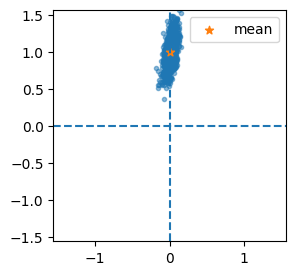

In [126]:
def viz(x):
    
    x = x.numpy()

    plt.figure(figsize=(3,  3))
    vmax = np.max(np.abs(x))

    plt.axhline(0, ls="--")
    plt.axvline(0, ls="--")
    plt.scatter(x[:, 0], x[:, 1], marker=".", alpha=0.5)
    
    mu = np.mean(x, axis=0)
    plt.scatter([mu[0]], [mu[1]], marker='*', label="mean")

    
    plt.ylim(-vmax, vmax)
    plt.xlim(-vmax, vmax)
    
    plt.legend()
    
viz(feature(X))

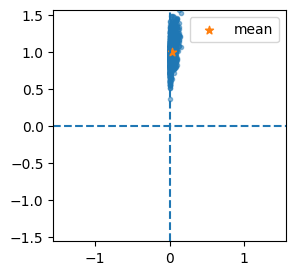

In [127]:
A = true_model(X)
viz(A)

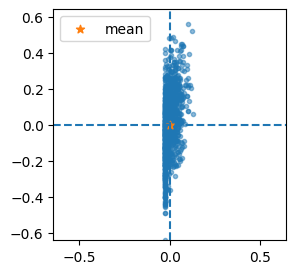

In [128]:

A_mu = torch.mean(A, axis=0)

A_centered = A  - A_mu

viz(A_centered)

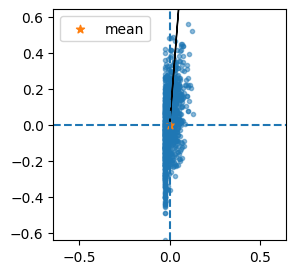

In [140]:
eigvals, eigvecs = torch.linalg.eigh(torch.cov(A_centered.T))

eigvecs = eigvecs[:, torch.argsort(-eigvals)]
eigval = eigvals[torch.argsort(-eigvals)]

eigval1 = eigvals[0]
u1 = eigvecs[:, 0]

A_centered_on_u1 = A_centered @ u1 

viz(A_centered)

plt.arrow(0, 0, 5*u1[0], 5*u1[1], label="eigvec1")


In [130]:
eigval1

tensor(0.0008)

(array([  1.,  18.,  55., 134., 215., 249., 185., 102.,  33.,   8.]),
 array([-0.64256525, -0.52150375, -0.4004423 , -0.2793808 , -0.15831932,
        -0.03725785,  0.08380363,  0.20486511,  0.3259266 ,  0.44698808,
         0.56804955]),
 <BarContainer object of 10 artists>)

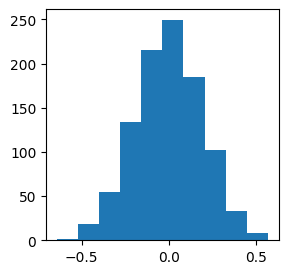

In [131]:
plt.figure(figsize=(3, 3))
plt.hist(A_centered_on_u1)

In [132]:
(true_model(X) - A_mu) @ u1

tensor([-2.6727e-01, -3.0887e-01, -1.0367e-01, -3.4130e-01, -2.8540e-02,
        -1.1807e-01,  2.2720e-01,  9.1401e-02, -2.4605e-01,  1.0002e-01,
         1.2400e-01,  5.1683e-02,  8.5578e-02, -4.4318e-01, -8.8245e-02,
        -1.0222e-01,  1.8163e-01, -1.0153e-01,  2.5257e-02, -5.7492e-02,
         3.0094e-02, -2.2841e-02,  8.6751e-02,  6.6684e-02, -1.3895e-02,
        -6.0689e-02,  1.4281e-01,  4.1987e-01,  1.5242e-01, -1.1786e-01,
         2.7149e-02, -4.4694e-01, -1.5788e-01, -2.1278e-01, -2.5087e-02,
         1.7264e-01, -1.0085e-01, -2.2661e-01, -1.3269e-01, -1.0813e-01,
        -3.8536e-02,  4.1265e-02, -2.2087e-01, -8.3454e-03, -5.0893e-02,
         2.7433e-03, -1.7791e-01,  3.2568e-01,  2.4426e-01, -5.4260e-02,
         1.9528e-02,  7.0858e-02,  2.2644e-01, -3.5517e-02, -3.0527e-01,
        -3.1985e-01,  4.5023e-03,  2.5311e-01,  6.4699e-02, -1.1205e-02,
         2.2781e-01,  2.7468e-01,  6.8574e-02,  5.9202e-02, -1.9411e-01,
         2.1386e-01, -2.9666e-01, -5.6748e-02, -4.4

In [133]:
A_centered_on_u1[:10]

tensor([-0.2673, -0.3089, -0.1037, -0.3413, -0.0285, -0.1181,  0.2272,  0.0914,
        -0.2460,  0.1000])

In [134]:
ds = TensorDataset(X, A_centered_on_u1)
data_loader = DataLoader(
    ds,
    batch_size=100,
    num_workers=2,
    shuffle=True
)

In [135]:
def ano():
    
    count = 0
    for x, y in iter(data_loader):
        count += x.shape[0]
        
    return count
ano()

1000

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name   | Type              | Params
---------------------------------------------
0 | approx | ApproximatorNaive | 3     
---------------------------------------------
3         Trainable params
0         Non-trainable params
3         Total params
0.000     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

[batch_ix=  0] mse_loss=0.1325
tensor([[0.0899],
        [0.9323],
        [0.0017],
        [0.1920],
        [0.0174]])
[batch_ix=  0] mse_loss=0.0161
tensor([[2.9201e-03],
        [1.6626e-07],
        [5.3466e-03],
        [8.4627e-04],
        [3.1089e-07]])
[batch_ix=  0] mse_loss=0.0134
tensor([[2.3396e-09],
        [7.8688e-08],
        [3.2203e-03],
        [2.5899e-02],
        [4.4829e-02]])
[batch_ix=  0] mse_loss=0.0151
tensor([[1.9287e-03],
        [1.0976e-02],
        [8.5683e-07],
        [5.4415e-07],
        [1.2140e-01]])


`Trainer.fit` stopped: `max_epochs=50` reached.


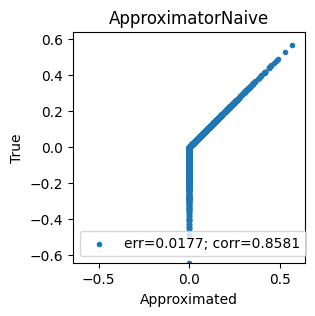

In [136]:
class ApproximatorNaive(nn.Module):
    def __init__(self, k=1):
        super().__init__()
        
        self.lin1 = nn.Linear(2, out_features=1)
        
    def forward(self, x):
        
        out = self.lin1(x)
        out = F.relu(out)
        
        return out
    
    
class ApproximatorBetter(nn.Module):
    def __init__(self, k=1):
        super().__init__()
        
        self.lin1 = nn.Linear(in_features=2, out_features=1)
        
        self.lin2 = nn.Linear(in_features=1, out_features=1)

        
    def forward(self, x):
        out = self.lin1(x)
        out = F.relu(out)
        out = self.lin2(out)
        
        return out
    

class ModelWrapper(pl.LightningModule):
    def __init__(
        self,
        approx,
    ):
        super().__init__()

        self.approx = approx
      

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-1, weight_decay=0)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x, a = train_batch
        a = a.unsqueeze(1)

        ah = self.approx(x)

        
        assert ah.shape == a.shape
        
        loss = ((a - ah) ** 2).sum(dim=1)
        loss = loss.mean()

        if self.current_epoch % 15 == 0 and batch_idx == 0:
            print(
                f"[batch_ix={batch_idx:3d}] mse_loss={loss.detach().numpy():.4f}"
            )
            print(((a-ah) ** 2).detach()[:5])


        return loss

def train(approx_cls, epochs=50):
    pl.seed_everything(1)
    
    model = approx_cls()
    
    wrapped_model = ModelWrapper(model)
    
 
    trainer = pl.Trainer(
        accelerator="cpu",
        max_epochs=epochs,
        enable_checkpointing=False,
    )

    trainer.fit(
        wrapped_model,
        data_loader
    )

    ah_on_u1 = model(X).detach().squeeze()
    
    vmax = np.abs(
        np.stack([A_centered_on_u1, ah_on_u1])
    ).max()

    
    assert ah_on_u1.shape == A_centered_on_u1.shape
    
    err = ((ah_on_u1 - A_centered_on_u1)**2).mean()
    
    plt.figure(figsize=(3, 3))
    plt.title(f"{model.__class__.__name__}")
    plt.scatter(
        ah_on_u1, A_centered_on_u1,
        marker=".",
        label=f"err={err:.4f}; corr={np.corrcoef(ah_on_u1, A_centered_on_u1)[0, 1]:.4f}"
    )
    
    plt.ylabel("True"); plt.xlabel("Approximated")
    plt.ylim(-vmax, vmax); plt.xlim(-vmax, vmax)
    plt.legend()

train(ApproximatorNaive, epochs=50)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name   | Type               | Params
----------------------------------------------
0 | approx | ApproximatorBetter | 5     
----------------------------------------------
5         Trainable params
0         Non-trainable params
5         Total params
0.000     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]

[batch_ix=  0] mse_loss=0.8305
tensor([[0.9657],
        [2.0473],
        [0.8098],
        [0.4823],
        [0.5107]])
[batch_ix=  0] mse_loss=0.0006
tensor([[7.9456e-06],
        [1.9806e-07],
        [1.3258e-06],
        [3.7797e-06],
        [7.6644e-08]])
[batch_ix=  0] mse_loss=0.0000
tensor([[6.0856e-05],
        [1.4621e-06],
        [4.7185e-07],
        [2.7237e-06],
        [3.1309e-08]])
[batch_ix=  0] mse_loss=0.0000
tensor([[3.6152e-06],
        [6.2967e-07],
        [3.2368e-07],
        [1.6917e-07],
        [9.4450e-09]])


`Trainer.fit` stopped: `max_epochs=50` reached.


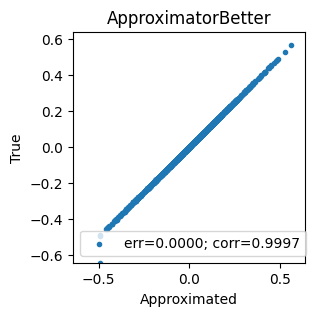

In [137]:
train(ApproximatorBetter, epochs=50)